In [33]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_excel('ecommerce_sales_data.xlsx')

pd.set_option('display.max_rows', None)
pd.set_option('display.max_columns', None)

print(df)

display(df.head(7))
display(df.tail(5))

print("\ncấu trúc dữ liệu:")
df.info()

print("\nmô tả:")
display(df.describe())

    OrderID        Date CustomerID Product_Category              Product_Name  \
0   ORD0001  2025-11-24    CUST027         Clothing                     Jeans   
1   ORD0002  2025-02-27    CUST025      Electronics                Smartphone   
2   ORD0003  2025-01-13    CUST025            Books    Machine Learning Intro   
3   ORD0004  2025-05-21    CUST002   Home & Kitchen              Coffee Maker   
4   ORD0005  2025-05-06    CUST008      Electronics                    Laptop   
5   ORD0006  2025-04-25    CUST027      Electronics                    Laptop   
6   ORD0007  2025-03-13    CUST002            Books     Data Science Handbook   
7   ORD0008  2025-02-22    CUST026            Books    Machine Learning Intro   
8   ORD0009  2025-12-13    CUST011         Clothing                   T-Shirt   
9   ORD0010  2025-10-07    CUST013      Electronics                    Laptop   
10  ORD0011  2025-02-14    CUST009         Clothing                  Sneakers   
11  ORD0012  2025-10-30    C

,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
0,ORD0001,2025-11-24,CUST027,Clothing,Jeans,6,93.20,0.12,Central
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,NaN,South
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North
5,ORD0006,2025-04-25,CUST027,Electronics,Laptop,3,138.23,NaN,Central
6,ORD0007,2025-03-13,CUST002,Books,Data Science Handbook,1,71.97,0.04,South


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region
95,ORD0096,2025-12-19,CUST021,Books,Python for Data Analysis,4,73.96,0.14,North
96,ORD0097,2025-10-13,CUST010,Home & Kitchen,Microwave,7,73.63,0.12,North
97,ORD0098,2025-04-23,NaN,Books,Python for Data Analysis,7,136.39,NaN,North
98,ORD0099,2025-12-17,CUST021,Home & Kitchen,Microwave,3,18.42,0.02,Central
99,ORD0100,2025-06-16,CUST017,Home & Kitchen,Coffee Maker,10,107.48,NaN,Central



cấu trúc dữ liệu:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   OrderID           100 non-null    object 
 1   Date              100 non-null    object 
 2   CustomerID        95 non-null     object 
 3   Product_Category  100 non-null    object 
 4   Product_Name      100 non-null    object 
 5   Quantity          100 non-null    int64  
 6   UnitPrice         100 non-null    float64
 7   Discount          65 non-null     float64
 8   Region            100 non-null    object 
dtypes: float64(2), int64(1), object(6)
memory usage: 7.2+ KB

mô tả:


,Quantity,UnitPrice,Discount
count,100.000000,100.000000,65.000000
mean,5.150000,153.546200,0.141385
std,2.896794,77.360231,0.079134
min,-5.000000,11.610000,0.010000
25%,3.000000,84.445000,0.080000
50%,5.000000,154.880000,0.150000
75%,7.000000,215.792500,0.210000
max,10.000000,296.490000,0.300000


In [22]:
print(df.isnull().sum())

OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
Revenue             0
Year                0
Month               0
DayOfWeek           0
Price_Segment       0
dtype: int64


In [23]:
df['Discount'] = df['Discount'].fillna(0)
df['CustomerID'] = df['CustomerID'].fillna('GUEST')
print(df.isnull().sum())


--- 4. Kiểm tra lại giá trị thiếu ---
OrderID             0
Date                0
CustomerID          0
Product_Category    0
Product_Name        0
Quantity            0
UnitPrice           0
Discount            0
Region              0
Revenue             0
Year                0
Month               0
DayOfWeek           0
Price_Segment       0
dtype: int64


In [24]:
df['Date'] = pd.to_datetime(df['Date'])
df.drop_duplicates(inplace=True)

In [32]:
print("Tạo cột Revenue")
df['Revenue'] = df['Quantity'] * df['UnitPrice'] * (1 - df['Discount'])

df['Year'] = df['Date'].dt.year

df['Month'] = df['Date'].dt.month

df['DayOfWeek'] = df['Date'].dt.day_name()

print("Tạo cột phân loại Price_Segment ")
def categorize_price(price):
    if price >= 150:
        return 'High'
    elif price >= 50:
        return 'Medium'
    else:
        return 'Low'

df['Price_Segment'] = df['UnitPrice'].apply(categorize_price)

print("\nKết quả sau khi thêm các cột mới:")
display(df[['Revenue', 'Year', 'Month', 'DayOfWeek', 'Price_Segment']].head())

Tạo cột Revenue
Tạo cột phân loại Price_Segment 

Kết quả sau khi thêm các cột mới:


,Revenue,Year,Month,DayOfWeek,Price_Segment
0,492.0960,2025,11,Monday,Medium
1,1346.7000,2025,2,Thursday,Medium
2,1539.6480,2025,1,Monday,High
3,593.5842,2025,5,Wednesday,High
4,841.5785,2025,5,Tuesday,Medium


In [29]:
print("Khu vực North, Revenue > 300")
display(df[(df['Region'] == 'North') & (df['Revenue'] > 300)])

print("Đơn hàng Electronics không giảm giá")
count = df[(df['Product_Category'] == 'Electronics') & (df['Discount'] == 0)].shape[0]
print(f"Số lượng: {count}")

print("Đơn hàng từ tháng 3 đến tháng 6")
display(df[(df['Month'] >= 3) & (df['Month'] <= 6)])

print("Top 10 đơn hàng có doanh thu cao nhất (OrderID, Product_Name, Revenue)")
top_10 = df[['OrderID', 'Product_Name', 'Revenue']].sort_values(by='Revenue', ascending=False).head(10)
display(top_10)

print("Đơn hàng có Quantity nhiều nhất")
display(df[df['Quantity'] == df['Quantity'].max()])

--- 1. Khu vực North, Revenue > 300 ---


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
2,ORD0003,2025-01-13,CUST025,Books,Machine Learning Intro,9,178.20,0.04,North,1539.6480,2025,1,Monday,High
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
25,ORD0026,2025-10-07,GUEST,Books,Data Science Handbook,6,130.19,0.00,North,781.1400,2025,10,Tuesday,Medium
31,ORD0032,2025-01-04,CUST018,Electronics,Headphones,7,200.26,0.20,North,1121.4560,2025,1,Saturday,High
33,ORD0034,2025-12-24,CUST009,Electronics,Headphones,8,227.78,0.02,North,1785.7952,2025,12,Wednesday,High
36,ORD0037,2025-05-23,CUST014,Electronics,Monitor,8,133.29,0.26,North,789.0768,2025,5,Friday,Medium
37,ORD0038,2025-03-21,CUST029,Electronics,Smartphone,6,61.01,0.04,North,351.4176,2025,3,Friday,Medium
44,ORD0045,2025-07-03,CUST016,Clothing,T-Shirt,6,242.41,0.21,North,1149.0234,2025,7,Thursday,High
45,ORD0046,2025-06-26,CUST003,Books,Python for Data Analysis,5,203.60,0.22,North,794.0400,2025,6,Thursday,High



--- 2. Đơn hàng Electronics không giảm giá ---
Số lượng: 8

--- 3. Đơn hàng từ tháng 3 đến tháng 6 ---


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
3,ORD0004,2025-05-21,CUST002,Home & Kitchen,Coffee Maker,3,199.86,0.01,North,593.5842,2025,5,Wednesday,High
4,ORD0005,2025-05-06,CUST008,Electronics,Laptop,7,144.85,0.17,North,841.5785,2025,5,Tuesday,Medium
5,ORD0006,2025-04-25,CUST027,Electronics,Laptop,3,138.23,0.00,Central,414.6900,2025,4,Friday,Medium
6,ORD0007,2025-03-13,CUST002,Books,Data Science Handbook,1,71.97,0.04,South,69.0912,2025,3,Thursday,Medium
16,ORD0017,2025-04-22,CUST023,Clothing,T-Shirt,7,227.83,0.20,Central,1275.8480,2025,4,Tuesday,High
17,ORD0018,2025-04-30,CUST011,Home & Kitchen,Microwave,10,205.11,0.28,South,1476.7920,2025,4,Wednesday,High
22,ORD0023,2025-04-12,CUST029,Clothing,T-Shirt,7,147.79,0.17,Central,858.6599,2025,4,Saturday,Medium
27,ORD0028,2025-04-23,CUST009,Home & Kitchen,Coffee Maker,4,66.39,0.00,North,265.5600,2025,4,Wednesday,Medium
30,ORD0031,2025-05-23,CUST024,Clothing,Jacket,2,80.76,0.00,North,161.5200,2025,5,Friday,Medium
32,ORD0033,2025-03-23,CUST018,Books,Python for Data Analysis,1,11.61,0.12,North,10.2168,2025,3,Sunday,Low



--- 4. Top 10 đơn hàng có doanh thu cao nhất (OrderID, Product_Name, Revenue) ---


,OrderID,Product_Name,Revenue
83,ORD0084,T-Shirt,2584.5000
61,ORD0062,Laptop,2251.2730
49,ORD0050,Coffee Maker,2223.2628
51,ORD0052,Coffee Maker,1967.3100
33,ORD0034,Headphones,1785.7952
15,ORD0016,Jeans,1780.8480
89,ORD0090,Coffee Maker,1730.4000
80,ORD0081,Laptop,1601.7120
2,ORD0003,Machine Learning Intro,1539.6480
8,ORD0009,T-Shirt,1530.3576



--- 5. Đơn hàng có Quantity nhiều nhất ---


,OrderID,Date,CustomerID,Product_Category,Product_Name,Quantity,UnitPrice,Discount,Region,Revenue,Year,Month,DayOfWeek,Price_Segment
1,ORD0002,2025-02-27,CUST025,Electronics,Smartphone,10,134.67,0.00,South,1346.700,2025,2,Thursday,Medium
17,ORD0018,2025-04-30,CUST011,Home & Kitchen,Microwave,10,205.11,0.28,South,1476.792,2025,4,Wednesday,High
57,ORD0058,2025-11-13,CUST003,Books,Data Science Handbook,10,147.66,0.10,Central,1328.940,2025,11,Thursday,Medium
61,ORD0062,2025-12-27,CUST015,Electronics,Laptop,10,232.09,0.03,Central,2251.273,2025,12,Saturday,High
66,ORD0067,2025-05-29,CUST001,Electronics,Laptop,10,92.86,0.00,North,928.600,2025,5,Thursday,Medium
83,ORD0084,2025-11-28,CUST001,Clothing,T-Shirt,10,258.45,0.00,Central,2584.500,2025,11,Friday,High
99,ORD0100,2025-06-16,CUST017,Home & Kitchen,Coffee Maker,10,107.48,0.00,Central,1074.800,2025,6,Monday,Medium


In [30]:
print("Tổng doanh thu theo khu vực")
region_revenue = df.groupby('Region')['Revenue'].sum()
display(region_revenue)
print("Khu vực có doanh thu cao nhất:", region_revenue.idxmax())

print("Trung bình Quantity và UnitPrice theo danh mục")
category_stats = df.groupby('Product_Category')[['Quantity', 'UnitPrice']].mean()
display(category_stats)

print("Số lượng đơn hàng theo tháng")
monthly_orders = df.groupby('Month').size()
display(monthly_orders)
print("Tháng có số lượng đơn hàng nhiều nhất:", monthly_orders.idxmax())

print("Top 3 khách hàng chi tiêu cao nhất (loại trừ 'GUEST')")
top_customers = df[df['CustomerID'] != 'GUEST'].groupby('CustomerID')['Revenue'].sum().nlargest(3)
display(top_customers)

Tổng doanh thu theo khu vực


,Revenue
Region,
Central,30679.9509
North,23579.3016
South,18995.3702


Khu vực có doanh thu cao nhất: Central
Trung bình Quantity và UnitPrice theo danh mục


,Quantity,UnitPrice
Product_Category,,
Books,5.071429,124.435000
Clothing,5.321429,167.446786
Electronics,5.551724,166.513103
Home & Kitchen,4.620690,141.211724


Số lượng đơn hàng theo tháng


,0
Month,
1,7
2,12
3,7
4,11
5,11
6,4
7,9
8,7
9,1


Tháng có số lượng đơn hàng nhiều nhất: 2
Top 3 khách hàng chi tiêu cao nhất (loại trừ 'GUEST')


,Revenue
CustomerID,
CUST025,5505.3496
CUST004,5033.4404
CUST017,4553.5066


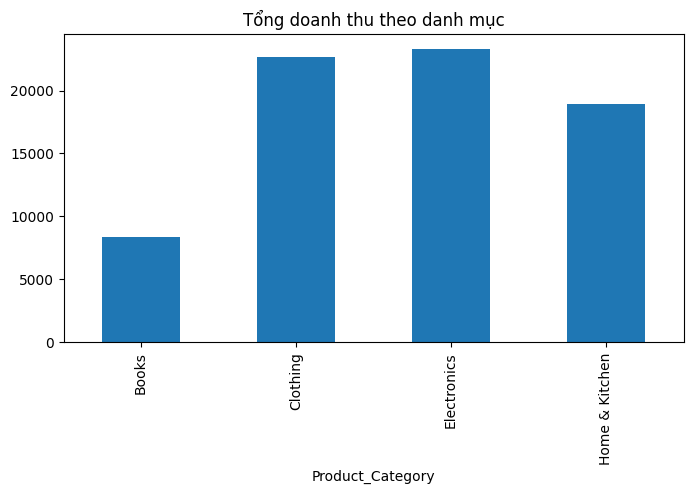

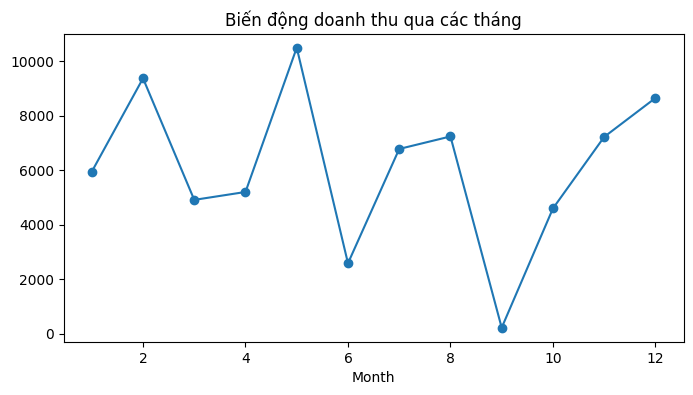

In [28]:
plt.figure(figsize=(8,4))
df.groupby('Product_Category')['Revenue'].sum().plot(kind='bar')
plt.title('Tổng doanh thu theo danh mục')
plt.show()

plt.figure(figsize=(8,4))
df.groupby('Month')['Revenue'].sum().plot(kind='line', marker='o')
plt.title('Biến động doanh thu qua các tháng')
plt.show()